In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# read csv files
superhero_df = pd.read_csv('superhero.csv')    # source 1: superhero movies
fantasy_df = pd.read_csv('fantasy.csv')        # source 2: fantasy movies
franchise_df = pd.read_csv('franchise.csv')    # source 3: franchise keyword list
brands_df = pd.read_csv('brands.csv')          # source 4: brands keyword list
animation_df = pd.read_csv('animation.csv')    # source 5: animation movies (2020-2025)

# data cleaning and prepping it up
def clean_data(df):
    
    # cleaning up the money column (lifetime gross)
    if 'Lifetime Gross' in df.columns:
        # replacing the dashes (-) which mean missing data with '0'
        df['Lifetime Gross'] = df['Lifetime Gross'].replace('-', '0')
        
        # getting rid of the $ and commas and changing the column type to a number (float)
        df['Lifetime Gross'] = df['Lifetime Gross'].str.replace('[\$,]', '', regex=True).astype(float)

    # cleaning the release date column and pulling out just the year
    if 'Release Date' in df.columns:
        # pulling out the year (the last 4 digits) from the full date string
        df['Year'] = df['Release Date'].str.slice(-4)
        # turning the year into a number
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        
    # cleaning the 'releases' count column for question 2 (the franchise/brand count)
    if 'Releases' in df.columns:
        # this checks if the column accidentally became a string type during import
        if df['Releases'].dtype == object:
            # if it's a string, we clean up any extra symbols (though it shouldn't have any)
            df['Releases'] = df['Releases'].str.replace('[\$,]', '', regex=True)
        
        # turning it into a number (float) just to be safe
        df['Releases'] = pd.to_numeric(df['Releases'], errors='coerce')

    return df

In [3]:
# running the cleaning function on all the data tables
superhero_df = clean_data(superhero_df)
fantasy_df = clean_data(fantasy_df)
franchise_df = clean_data(franchise_df)
brands_df = clean_data(brands_df)
animation_df = clean_data(animation_df)

# analysis - starting the analysis part, calculating the answers for the project questions

# preparing data for question 2 analysis (merging franchises and brands data)
franchise_plot_df = franchise_df[['Franchise', 'Releases']].rename(columns={'Franchise': 'Name'}) # only keeping the name and count columns
brands_plot_df = brands_df[['Brand', 'Releases']].rename(columns={'Brand': 'Name'})
combined_plot_df = pd.concat([franchise_plot_df, brands_plot_df], ignore_index=True) # slamming the two tables together
top_5_releases_df = combined_plot_df.sort_values(by='Releases', ascending=False).head(5).reset_index(drop=True) # finding the top 5 biggest ones

In [4]:
# question 1: which movie genre has the older average release year?
avg_superhero_year = superhero_df['Year'].mean() # calculating the mean year for superhero
avg_fantasy_year = fantasy_df['Year'].mean()     # calculating the mean year for fantasy

# question 2: which franchise/brand has the most movie titles (by releases)?
q2_winner_name = top_5_releases_df.iloc[0]['Name'] # just grabbing the top name from the list
q2_winner_count = top_5_releases_df.iloc[0]['Releases'] # and its release count
    
# question 3: what is the annual production rate for new animated films (2020-2025)?
total_animation = len(animation_df) # counting the total number of animated films
annual_rate = total_animation / 6   # dividing by 6 years (2020-2025)

# question 4: what is the average domestic gross of all top-grossing titles in the superhero genre?
avg_superhero_gross = superhero_df['Lifetime Gross'].mean() # calculating the mean lifetime gross

# question 5: what is the percentage of modern animated films containing "disney" or "pixar" keywords?
animation_df['Distributor'] = animation_df['Distributor'].fillna('') # replacing missing distributors with blank space so the filter doesn't crash

# filtering for titles where distributor contains 'disney' or 'pixar' (ignoring caps)
filtered_count = animation_df[
    animation_df['Distributor'].str.contains('disney|pixar', case=False, na=False)
].shape[0]

q5_percentage = (filtered_count / total_animation) * 100 if total_animation > 0 else 0 # simple percentage calculation


print("analysis results:")
print(f"  question 1: which movie genre has the older average release year?")
print(f"  -> average release year - superhero: {avg_superhero_year:.2f}")
print(f"  -> average release year - fantasy: {avg_fantasy_year:.2f}")
print(f"  question 2: which franchise/brand has the most movie titles?")
print(f"  -> overall top franchise/brand: {q2_winner_name} ({int(q2_winner_count)} releases)")
print(f"  question 3: what is the annual production rate for new animated films (2020-2025)?")
print(f"  -> annual production rate: {annual_rate:.2f} films/year")
print(f"  question 4: what is the average domestic gross of all top-grossing titles in the superhero genre?")
print(f"  -> average domestic gross (superhero): ${avg_superhero_gross:,.2f}")
print(f"  question 5: what is the percentage of modern animated films containing 'disney' or 'pixar' keywords?")
print(f"  -> percentage: {q5_percentage:.2f}%")

analysis results:
  question 1: which movie genre has the older average release year?
  -> average release year - superhero: 2010.84
  -> average release year - fantasy: 1997.43
  question 2: which franchise/brand has the most movie titles?
  -> overall top franchise/brand: Marvel Comics (86 releases)
  question 3: what is the annual production rate for new animated films (2020-2025)?
  -> annual production rate: 7.00 films/year
  question 4: what is the average domestic gross of all top-grossing titles in the superhero genre?
  -> average domestic gross (superhero): $248,908,639.95
  question 5: what is the percentage of modern animated films containing 'disney' or 'pixar' keywords?
  -> percentage: 14.29%


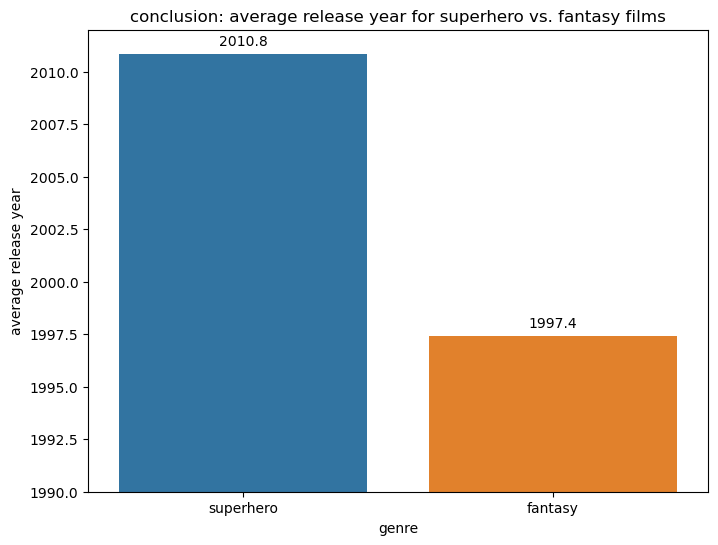

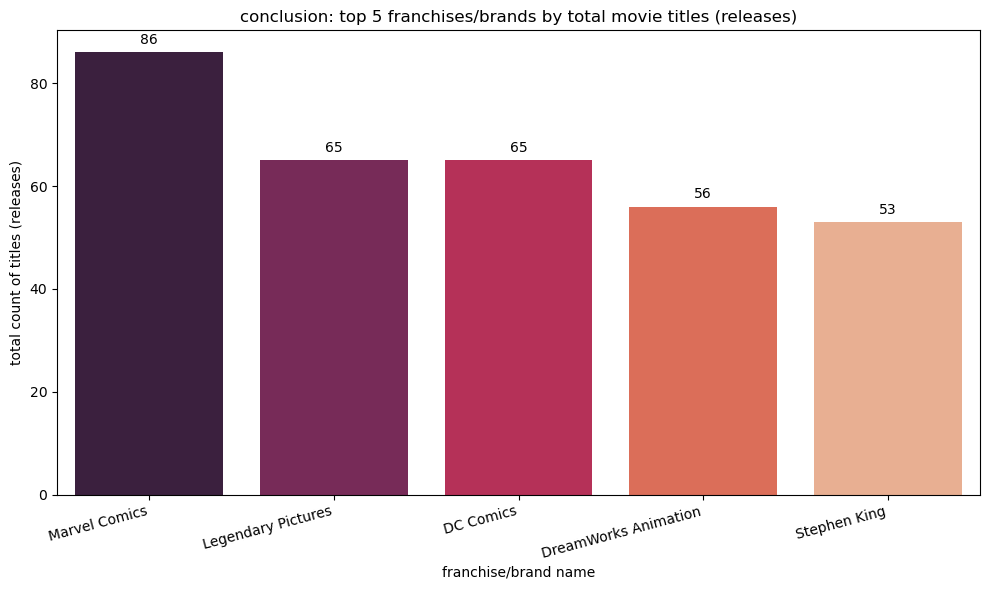

In [5]:
# plot 1: average release year (question 1)
plt.figure(figsize=(8, 6))
year_data = pd.DataFrame({
    'genre': ['superhero', 'fantasy'],
    'average release year': [avg_superhero_year, avg_fantasy_year]
})

# fixed the colors because python was throwing a fit (used 'tab10')
# stretched the y-axis (from 1990) so the fantasy bar doesn't look like a stub
ax = sns.barplot(x='genre', y='average release year', data=year_data, hue='genre', palette="tab10", legend=False)
plt.ylim(1990, np.ceil(year_data['average release year'].max() + 0.5))

# putting the actual data value on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("conclusion: average release year for superhero vs. fantasy films")
plt.ylabel("average release year")
plt.savefig('average_release_year_plot.png')


# plot 2: top 5 franchise/brands by releases (question 2)
plt.figure(figsize=(10, 6))

# plotting the top 5 biggest hitters we found earlier
ax = sns.barplot(x='Name', y='Releases', data=top_5_releases_df, hue='Name', palette="rocket", legend=False)

# putting the actual count value on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title(f"conclusion: top 5 franchises/brands by total movie titles (releases)")
plt.ylabel("total count of titles (releases)")
plt.xlabel("franchise/brand name")
plt.xticks(rotation=15, ha='right') # tilted the names so they don't overlap
plt.tight_layout() # made sure everything fits
plt.savefig('top_5_franchise_brand_plot.png')

#### At first, this project was supposed to use regular web scraping techniques (like parsing static HTML) to collect data from Box Office Mojo, just like we learned in class. But once I started coding, I realized that the tables and data I needed on the Box Office Mojo website are actually loaded through dynamic JavaScript. Because of that, the usual static scraping tools, such as requests and basic BeautifulSoup, couldn’t access the information. To work around this, I switched to manually downloading the CSV files that Box Office Mojo makes available. To help adjust the project, clean the CSV files, deal with inconsistent column names, and build the analysis and graphs, I used ChatGPT and Gemini. Using those resources made it possible for me to to complete the data analysis parts of the assignment, even though the original data-collection method didn’t work due to the website’s dynamic content.